##1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV

- pandas as pd: Digunakan untuk manipulasi dan analisis data, terutama dengan objek DataFrame.
- numpy as np: Menyediakan dukungan untuk array multi-dimensi besar dan fungsi matematika.
matplotlib.pyplot as plt: Pustaka plotting untuk membuat visualisasi statis, interaktif, dan animasi di Python.
- seaborn as sns: Pustaka visualisasi data statistik berdasarkan matplotlib, menyediakan antarmuka tingkat tinggi untuk menggambar grafik statistik yang menarik dan informatif.
- sklearn.model_selection.train_test_split: Digunakan untuk memisahkan data menjadi set pelatihan dan pengujian.
- sklearn.preprocessing.StandardScaler, OneHotEncoder: Alat prapemrosesan. StandardScaler menskala fitur numerik agar memiliki rata-rata nol dan varians unit, sementara OneHotEncoder mengubah data kategorikal menjadi array numerik one-hot.
- sklearn.compose.ColumnTransformer: Memungkinkan langkah-langkah prapemrosesan yang berbeda diterapkan pada kolom data yang berbeda.
- sklearn.pipeline.Pipeline: Menggabungkan beberapa langkah pemrosesan menjadi satu estimator Scikit-learn.
- sklearn.impute.SimpleImputer: Digunakan untuk menangani nilai yang hilang dengan mengisinya menggunakan strategi yang ditentukan (misalnya, mean, median, mode).
- sklearn.linear_model.LinearRegression, Ridge: Model linier untuk tugas regresi. Ridge menyertakan regularisasi L2.
- sklearn.ensemble.RandomForestRegressor: Metode pembelajaran ensemble untuk regresi, membangun beberapa pohon keputusan dan menggabungkan prediksinya.
- xgboost.XGBRegressor: Pustaka gradient boosting terdistribusi yang dioptimalkan yang dirancang agar sangat efisien, fleksibel, dan portabel.
sklearn.metrics.mean_squared_error, r2_score, mean_absolute_error: Fungsi untuk mengevaluasi kinerja model regresi.
- sklearn.model_selection.RandomizedSearchCV: Digunakan untuk penyetelan hyperparameter, mencari hyperparameter terbaik untuk model dari distribusi yang diberikan.

##2. Import Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path_drive = '/content/drive/MyDrive/ML/jakarta_house.csv'

df = None # Initialize df to None
try:
    df = pd.read_csv(path_drive)
    print("\n[SUKSES] Dataset jakarta_house.csv berhasil dimuat!")
    display(df.head()) # Display the head to confirm data loading
except Exception as e:
    print(f"\n[ERROR] File tidak ditemukan. Periksa jalur foldermu. Detail: {e}")

# Membersihkan kolom 'index' bawaan agar tidak masuk ke perhitungan statistik/korelasi
if df is not None and 'index' in df.columns:
    df = df.drop(columns=['index'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[SUKSES] Dataset jakarta_house.csv berhasil dimuat!


,index,price,district,city,bed_rooms,bath_rooms,carport,land_area,building_area
0,1,5900000000,Citra Garden,Jakarta Barat,2,4,2,250.0,350.0
1,2,2700000000,Jelambar,Jakarta Barat,4,2,0,100.0,225.0
2,3,2200000000,Jelambar,Jakarta Barat,3,3,0,60.0,140.0
3,4,1900000000,Jelambar,Jakarta Barat,3,2,0,60.0,120.0
4,5,2100000000,Tanjung Duren,Jakarta Barat,4,3,0,56.0,108.0


## 3. EKSPLORASI DATA (EDA) - STATISTIK DESKRIPTIF

In [ ]:
# Ensure df is loaded before proceeding
if df is None:
    try:
        df = pd.read_csv(path_drive)
        print("[INFO] DataFrame was None, re-loading data...")
    except Exception as e:
        print(f"[ERROR] Could not re-load data: {e}")
        # Exit or handle the error appropriately if df remains None
        exit()

# Menampilkan nilai mean, median (50%), std, min, max secara riil
display(df.describe())

# Menampilkan jumlah kecamatan (district) dan kota (city) terpopuler
print("B. STATISTIK DESKRIPTIF FITUR KATEGORIK")
display(df.describe(include=object))

,price,bed_rooms,bath_rooms,carport,land_area,building_area
count,1.000000e+04,10000.000000,10000.000000,10000.000000,9997.000000,9995.000000
mean,1.004029e+10,4.253500,3.521300,1.578900,296.610183,319.962481
std,2.004519e+10,3.176609,2.900136,1.743467,502.921686,357.676034
min,1.850000e+06,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.500000e+09,3.000000,2.000000,1.000000,100.000000,139.000000
50%,4.500000e+09,4.000000,3.000000,1.000000,177.000000,230.000000
75%,9.800000e+09,5.000000,4.000000,2.000000,335.000000,400.000000
max,9.000000e+11,63.000000,63.000000,31.000000,17714.000000,15331.000000


B. STATISTIK DESKRIPTIF FITUR KATEGORIK


,district,city
count,10000,10000
unique,253,5
top,Kelapa Gading,Jakarta Selatan
freq,435,3379


- df.describe(): Ini adalah fungsi dari pustaka Pandas yang menghasilkan statistik deskriptif ringkasan dari semua kolom numerik dalam DataFrame df.
- df.describe(include=object): untuk menampilkan statistik untuk kolom kategorikal, seperti jumlah nilai unik, nilai yang paling sering muncul, dan frekuensinya.

## 4. EKSPLORASI DATA (EDA) - IDENTIFIKASI KUALITAS DATA

In [ ]:
print("C. PENGECEKAN DATA KOSONG (MISSING VALUES)")
print(df.isnull().sum())

print("D. PENGECEKAN BARIS DUPLIKAT")
print(f"Jumlah baris data yang terduplikat: {df.duplicated().sum()}")

C. PENGECEKAN DATA KOSONG (MISSING VALUES)
price            0
district         0
city             0
bed_rooms        0
bath_rooms       0
carport          0
land_area        3
building_area    5
dtype: int64
D. PENGECEKAN BARIS DUPLIKAT
Jumlah baris data yang terduplikat: 526


## 5. EKSPLORASI DATA (EDA) - VISUALISASI

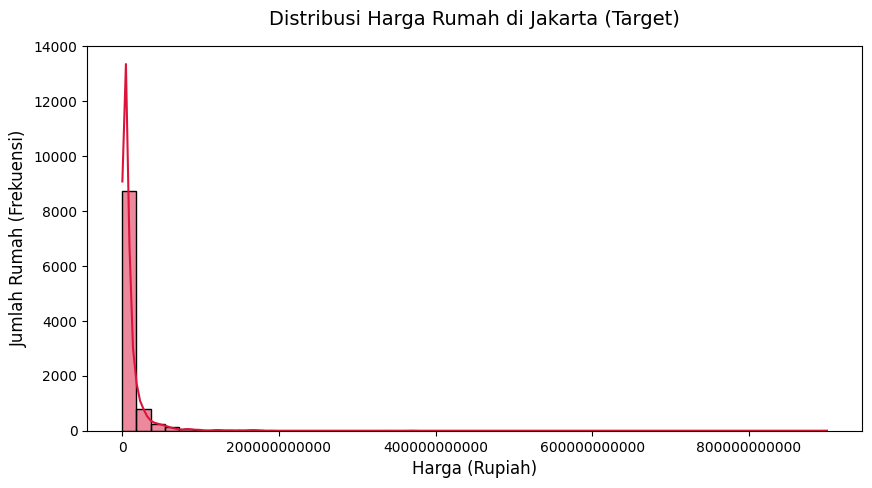

In [ ]:
# --- Grafik 1: Histogram Distribusi Target (Price) ---
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, bins=50, color='crimson')
plt.title('Distribusi Harga Rumah di Jakarta (Target)', fontsize=14, pad=15)
plt.xlabel('Harga (Rupiah)', fontsize=12)
plt.ylabel('Jumlah Rumah (Frekuensi)', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Supaya angka nol-nya kelihatan penuh, bukan eksponensial
plt.show()

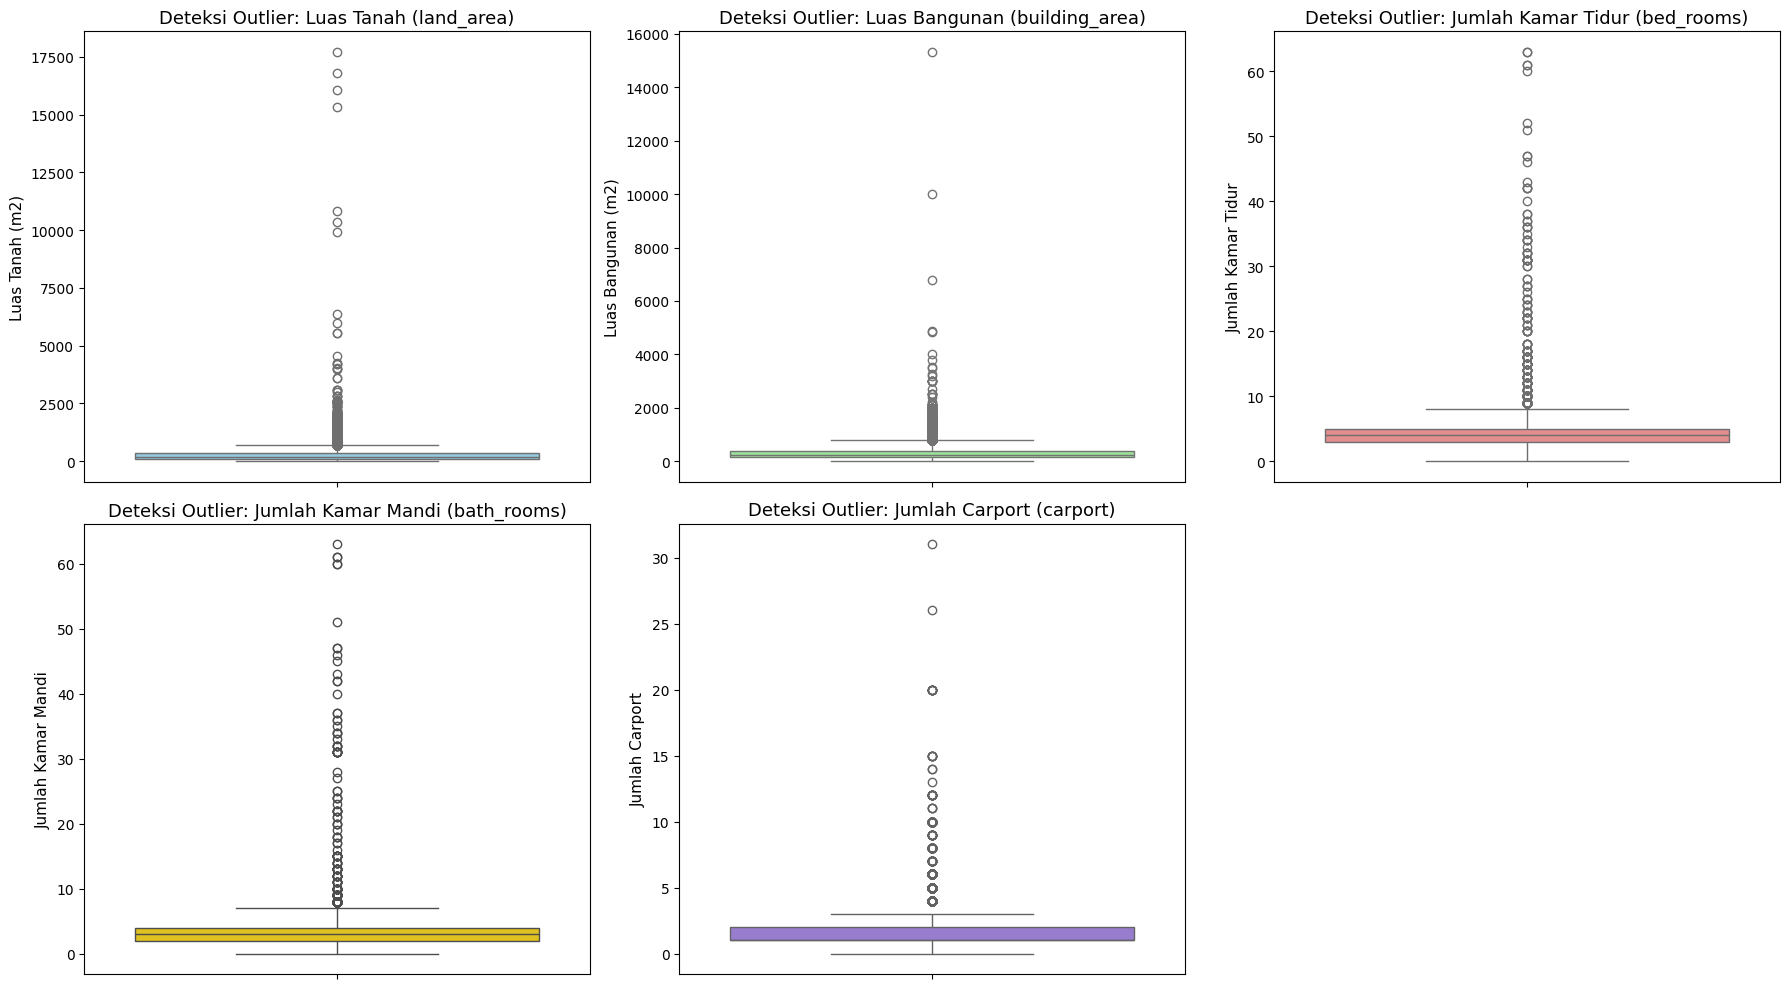

In [ ]:

# --- Grafik 2: Boxplot untuk Deteksi Outlier ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10)) # Adjusted figure size for better visibility

# land_area (axes[0,0])
sns.boxplot(data=df, y='land_area', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Deteksi Outlier: Luas Tanah (land_area)', fontsize=13)
axes[0, 0].set_ylabel('Luas Tanah (m2)', fontsize=11)

# building_area (axes[0,1])
sns.boxplot(data=df, y='building_area', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Deteksi Outlier: Luas Bangunan (building_area)', fontsize=13)
axes[0, 1].set_ylabel('Luas Bangunan (m2)', fontsize=11)

# bed_rooms (axes[0,2])
sns.boxplot(data=df, y='bed_rooms', ax=axes[0, 2], color='lightcoral') # Changed color for variety
axes[0, 2].set_title('Deteksi Outlier: Jumlah Kamar Tidur (bed_rooms)', fontsize=13)
axes[0, 2].set_ylabel('Jumlah Kamar Tidur', fontsize=11)

# bath_rooms (axes[1,0])
sns.boxplot(data=df, y='bath_rooms', ax=axes[1, 0], color='gold') # Changed color for variety
axes[1, 0].set_title('Deteksi Outlier: Jumlah Kamar Mandi (bath_rooms)', fontsize=13)
axes[1, 0].set_ylabel('Jumlah Kamar Mandi', fontsize=11)

# carport (axes[1,1])
sns.boxplot(data=df, y='carport', ax=axes[1, 1], color='mediumpurple') # Changed color for variety
axes[1, 1].set_title('Deteksi Outlier: Jumlah Carport (carport)', fontsize=13)
axes[1, 1].set_ylabel('Jumlah Carport', fontsize=11)

# Hide the unused subplot (axes[1,2])
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

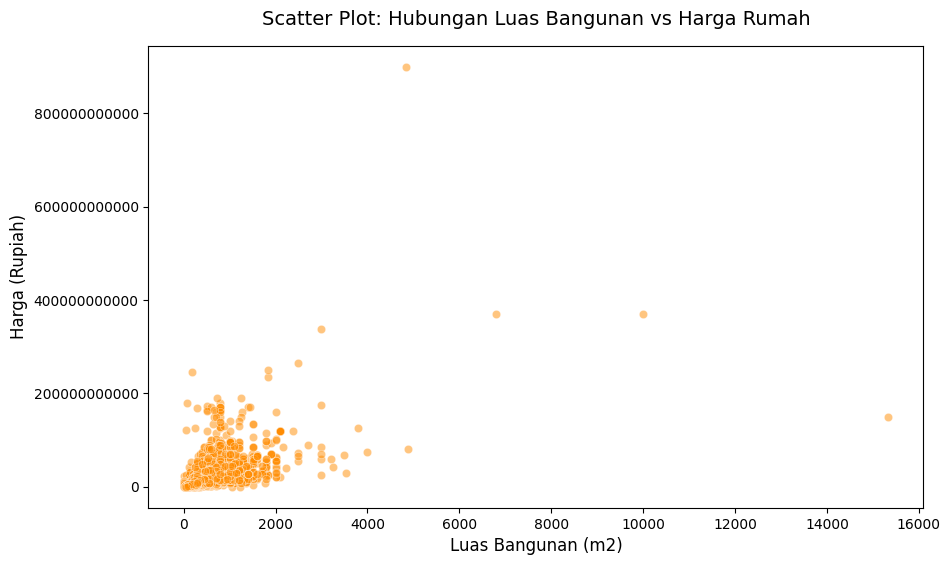

In [ ]:
# --- Grafik 3: Scatter Plot Hubungan Luas Bangunan vs Harga ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='building_area', y='price', alpha=0.5, color='darkorange')
plt.title('Scatter Plot: Hubungan Luas Bangunan vs Harga Rumah', fontsize=14, pad=15)
plt.xlabel('Luas Bangunan (m2)', fontsize=12)
plt.ylabel('Harga (Rupiah)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

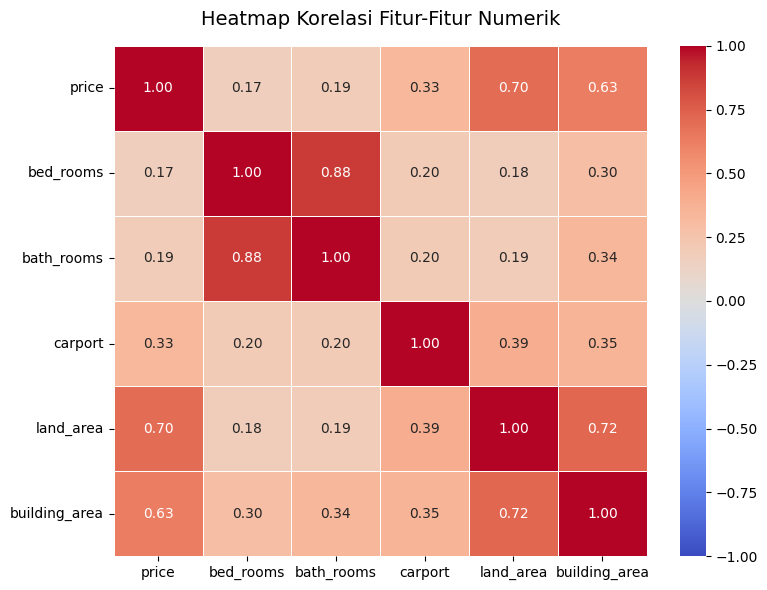

In [ ]:
# --- Grafik 4: Heatmap Korelasi Pearson ---
plt.figure(figsize=(8, 6))
# Menghitung korelasi otomatis antar kolom numerik murni
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Fitur-Fitur Numerik', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

##5. DATA CLEANING & REKAYASA FITUR (FEATURE ENGINEERING)


In [ ]:
# A. Menghapus Baris Duplikat
print(f"Jumlah baris sebelum hapus duplikat: {len(df)}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Jumlah baris setelah hapus duplikat: {len(df)}")

# B. Menangani Anomali Data (Filter Nilai Tidak Masuk Akal)
# Menghapus data rumah dengan harga terlalu rendah (misal < 100 juta) atau jumlah kamar 0
df = df[df['price'] >= 100_000_000].reset_index(drop=True)
df = df[(df['bed_rooms'] > 0) & (df['bath_rooms'] > 0)].reset_index(drop=True)
print(f"Jumlah baris setelah pembersihan anomali/noise: {len(df)}")

# C. Pembuatan Fitur Baru (Feature Engineering)
# Fitur 1: Rasio Luas Bangunan terhadap Luas Tanah (mengukur seberapa padat bangunan di lahan tersebut)
df['building_land_ratio'] = df['building_area'] / df['land_area']

# Fitur 2: Total Kamar (Gabungan kamar tidur dan kamar mandi)
df['total_rooms'] = df['bed_rooms'] + df['bath_rooms']

# Fitur 3: Rata-rata Luas per Kamar Tidur
df['area_per_bedroom'] = df['building_area'] / df['bed_rooms']

print("\n[SUKSES] Pembuatan fitur baru berhasil! Fitur saat ini:", list(df.columns))

Jumlah baris sebelum hapus duplikat: 10000
Jumlah baris setelah hapus duplikat: 9474
Jumlah baris setelah pembersihan anomali/noise: 9223

[SUKSES] Pembuatan fitur baru berhasil! Fitur saat ini: ['price', 'district', 'city', 'bed_rooms', 'bath_rooms', 'carport', 'land_area', 'building_area', 'building_land_ratio', 'total_rooms', 'area_per_bedroom']


##6. PEMISAHAN MATRIKS FITUR (X), TARGET (Y), DAN STRATIFIKASI DATA

In [ ]:
# Memisahkan Fitur (X) dan Target (Y)
X = df.drop(columns=['price'])
y = df['price']

# Transformasi Logaritma pada Target (Y) untuk mengatasi Right-Skewed Distribution
y_log = np.log1p(y)

# Membagi Data menjadi Train dan Test Set (Proporsi 80:20)
# Menggunakan random_state agar hasil pembagian konsisten setiap kali di-run
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"\nUkuran Data Train (X_train): {X_train.shape}")
print(f"Ukuran Data Test (X_test): {X_test.shape}")


Ukuran Data Train (X_train): (7378, 10)
Ukuran Data Test (X_test): (1845, 10)


##7. MEMBUAT PIPELINE UNTUK IMPUTASI, ENCODING, DAN SCALING

In [ ]:
# Mengelompokkan kolom berdasarkan tipe datanya
numerical_features = ['land_area', 'building_area', 'bed_rooms', 'bath_rooms',
                      'carport', 'building_land_ratio', 'total_rooms', 'area_per_bedroom']
categorical_features = ['district', 'city']

# A. Pipeline untuk Fitur Numerik: Imputasi Median -> Standard Scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Mengisi missing value (jika ada) dengan nilai median
    ('scaler', StandardScaler())                  # Skala data agar mean=0 dan std=1
])

# B. Pipeline untuk Fitur Kategorik: Imputasi Modus -> One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Mengisi missing value dengan modus
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Mengubah teks ke biner angka
])

# C. Menggabungkan kedua pipeline menggunakan ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 8. MENGEKSEKUSI PRAPEMROSESAN PADA DATA TRAIN & TEST

In [ ]:
# Fit dan transform pada data Train
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Cukup transform pada data Test (menghindari Data Leakage)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"Ukuran akhir matriks data train setelah One-Hot Encoding: {X_train_preprocessed.shape}")

Ukuran akhir matriks data train setelah One-Hot Encoding: (7378, 259)


##9. Pemodelan (Modeling)

In [ ]:
# Fungsi pembantu untuk menghitung metrik evaluasi (skala log diubah kembali ke Rupiah asli)
def evaluate_model_real_scale(model, X_test_bytes, y_test_log):
    # Prediksi dalam skala log
    y_pred_log = model.predict(X_test_bytes)

    # Kembalikan ke skala Rupiah asli menggunakan invers log (np.expm1)
    y_test_real = np.expm1(y_test_log)
    y_pred_real = np.expm1(y_pred_log)

    # Hitung metrik
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2 = r2_score(y_test_log, y_pred_log) # R2 dihitung pada varians skala log/distribusi normal

    return mae, rmse, r2

##10. MELATIH BASELINE MODEL & 3 ALGORITMA PEMBANDING

In [ ]:
# A. Baseline Model: Linear Regression (Sederhana)
baseline_model = LinearRegression()
baseline_model.fit(X_train_preprocessed, y_train)
mae_base, rmse_base, r2_base = evaluate_model_real_scale(baseline_model, X_test_preprocessed, y_test)

# B. Model 1: Ridge Regression (Linear Ber-regulerisasi)
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_preprocessed, y_train)
mae_ridge, rmse_ridge, r2_ridge = evaluate_model_real_scale(ridge_model, X_test_preprocessed, y_test)

# C. Model 2: Random Forest Regressor (Tree-Based / Ensemble)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_preprocessed, y_train)
mae_rf, rmse_rf, r2_rf = evaluate_model_real_scale(rf_model, X_test_preprocessed, y_test)

# D. Model 3: XGBoost Regressor (Gradient Boosting / SOTA)
xgb_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_preprocessed, y_train)
mae_xgb, rmse_xgb, r2_xgb = evaluate_model_real_scale(xgb_model, X_test_preprocessed, y_test)

##11. MERANGKUM PERFORMA AWAL (BEFORE TUNING)

In [ ]:
summary_before = pd.DataFrame({
    'Model': ['Baseline (Linear Regression)', 'Ridge Regression', 'Random Forest', 'XGBoost'],
    'MAE (Rupiah)': [mae_base, mae_ridge, mae_rf, mae_xgb],
    'RMSE (Rupiah)': [rmse_base, rmse_ridge, rmse_rf, rmse_xgb],
    'R2 Score': [r2_base, r2_ridge, r2_rf, r2_xgb]
})

print("TABEL PERFORMA MODEL SEBELUM TUNING")
display(summary_before.round(2))

TABEL PERFORMA MODEL SEBELUM TUNING


,Model,MAE (Rupiah),RMSE (Rupiah),R2 Score
0,Baseline (Linear Regression),4.873481e+09,3.306221e+10,0.73
1,Ridge Regression,4.920624e+09,3.417482e+10,0.74
2,Random Forest,3.042631e+09,9.982091e+09,0.88
3,XGBoost,2.745802e+09,8.848488e+09,0.89


##12. HYPERPARAMETER TUNING (PADA MODEL XGBoost)

In [ ]:
# 1. Menentukan ruang kombinasi parameter yang akan dicari (Hyperparameter Space)
ruang_param_xgb = {
    'n_estimators': [100, 200, 300],           # Jumlah pohon keputusan yang dibangun
    'max_depth': [4, 6, 8],                    # Kedalaman maksimum setiap pohon
    'learning_rate': [0.01, 0.05, 0.1, 0.2],   # Tingkat penyusutan bobot koreksi (eta)
    'subsample': [0.8, 1.0],                   # Rasio sampel baris untuk setin ap pohon
    'colsample_bytree': [0.8, 1.0]             # Rasio sampel kolom (fitur) untuk setiap pohon
}

# 2. Inisialisasi RandomizedSearchCV khusus untuk XGBoost
pencarian_param_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=ruang_param_xgb,
    n_iter=5,          # Mencoba 5 kombinasi parameter secara acak
    cv=3,              # 3-Fold Cross Validation (Validasi Silang)
    scoring='r2',      # Metrik optimasi berdasarkan R-squared
    random_state=42,
    n_jobs=-1
)

# 3. Proses pencarian kombinasi parameter terbaik pada data training
pencarian_param_xgb.fit(X_train_preprocessed, y_train)

# 4. Mengambil model XGBoost terbaik hasil dari tuning
model_xgb_terbaik = pencarian_param_xgb.best_estimator_

# 5. Evaluasi performa model XGBoost terbaik pada data testing
mae_xgb_tuned, rmse_xgb_tuned, r2_xgb_tuned = evaluate_model_real_scale(model_xgb_terbaik, X_test_preprocessed, y_test)

In [ ]:
print("TABEL PERFORMA MODEL XGBOOST SETELAH TUNING")
print(f"MAE (Mean Absolute Error): {mae_xgb_tuned:,.2f} Rupiah")
print(f"RMSE (Root Mean Squared Error): {rmse_xgb_tuned:,.2f} Rupiah")
print(f"R2 Score: {r2_xgb_tuned:.4f}")

TABEL PERFORMA MODEL XGBOOST SETELAH TUNING
MAE (Mean Absolute Error): 2,621,293,349.19 Rupiah
RMSE (Root Mean Squared Error): 8,304,090,781.79 Rupiah
R2 Score: 0.9041


##13. Evaluasi & Interpretasi

In [ ]:
# Menetapkan model terbaik ke model XGBoost hasil tuning dari langkah sebelumnya
model_terbaik = model_xgb_terbaik

# Lakukan prediksi pada data testing (Hasil dalam Skala Logaritma)
y_pred_log = model_terbaik.predict(X_test_preprocessed)

# Kembalikan nilai ke skala Rupiah asli menggunakan fungsi invers log (np.expm1)
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

# Hitung Residual (Selisih nilai aktual asli dengan nilai prediksi dalam skala log)
# Analisis residual standar dilakukan pada skala log agar distribusinya normal
residuals = y_test - y_pred_log

#14. PLOT PREDIKSI VS AKTUAL & ANALISIS RESIDUAL

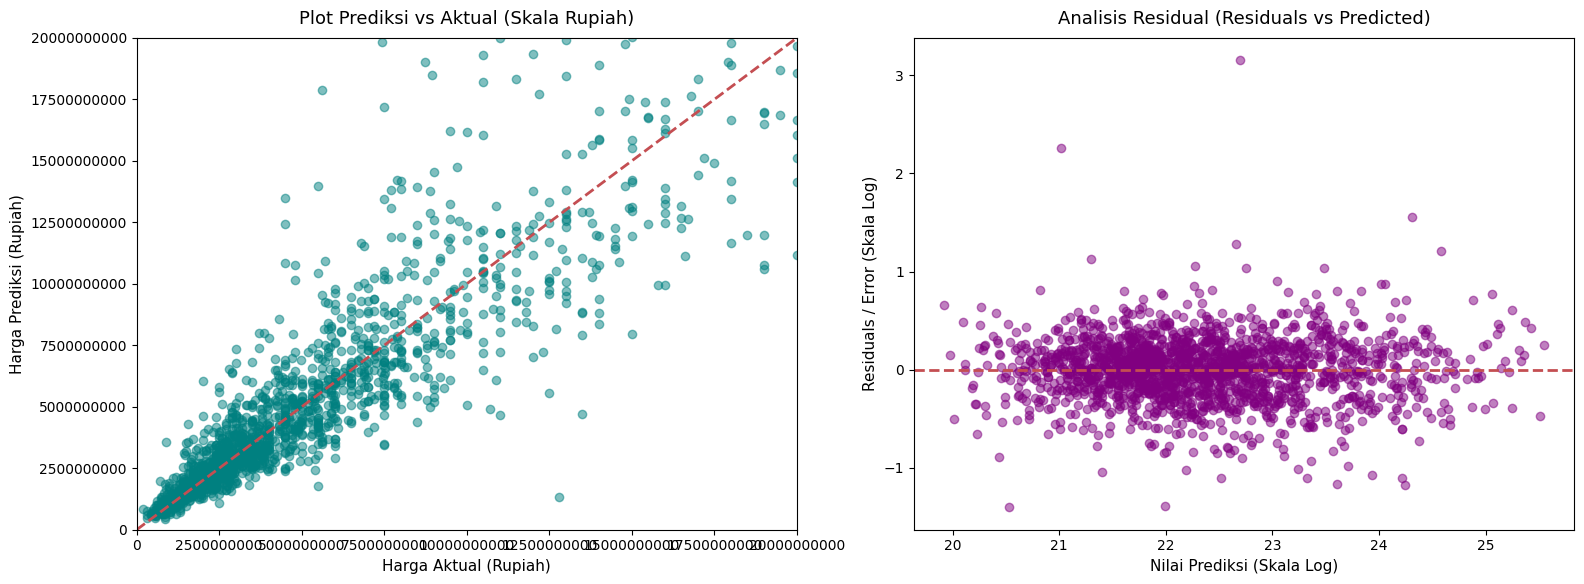

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Grafik A: Scatter Plot Prediksi vs Aktual (Skala Rupiah Asli)
# Membatasi visualisasi ke rentang harga dominan (misal hingga 20 Miliar) agar grafik lebih terbaca
axes[0].scatter(y_test_real, y_pred_real, alpha=0.5, color='teal')
max_val = min(max(y_test_real), 20_000_000_000) # Batas visualisasi maks 20M agar tidak terlalu kecil grafiknya
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2) # Garis diagonal sempurna
axes[0].set_xlim(0, max_val)
axes[0].set_ylim(0, max_val)
axes[0].set_title('Plot Prediksi vs Aktual (Skala Rupiah)', fontsize=13, pad=10)
axes[0].set_xlabel('Harga Aktual (Rupiah)', fontsize=11)
axes[0].set_ylabel('Harga Prediksi (Rupiah)', fontsize=11)
axes[0].ticklabel_format(style='plain', axis='both')

# Grafik B: Scatter Plot Analisis Residual (Residual vs Predicted)
axes[1].scatter(y_pred_log, residuals, alpha=0.5, color='purple')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2) # Garis ideal error = 0
axes[1].set_title('Analisis Residual (Residuals vs Predicted)', fontsize=13, pad=10)
axes[1].set_xlabel('Nilai Prediksi (Skala Log)', fontsize=11)
axes[1].set_ylabel('Residuals / Error (Skala Log)', fontsize=11)

plt.tight_layout()
plt.show()

#15. ANALISIS FEATURE IMPORTANCE

In [ ]:
importances = model_xgb_terbaik.feature_importances_

# 1. Mengambil nama fitur kategori setelah proses One-Hot Encoding
nama_kolom_kategorik = list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))

# 2. Menggabungkan seluruh nama fitur (Numerik + Kategorik hasil encoding)
gabungan_nama_fitur = numerical_features + nama_kolom_kategorik

# 3. Mengambil skor importance langsung dari model XGBoost terbaik
skor_kepentingan = model_xgb_terbaik.feature_importances_

# 4. Membuat DataFrame tabel agar rapi dan mudah dibaca
df_nilai_fitur = pd.DataFrame({
    'Nama Variabel Fitur': gabungan_nama_fitur,
    'Skor Kepentingan (Importance)': skor_kepentingan
})

# 5. Mengurutkan dari yang paling berpengaruh ke yang paling kecil
df_nilai_fitur_diurut = df_nilai_fitur.sort_values(by='Skor Kepentingan (Importance)', ascending=False).reset_index(drop=True)

# 6. Menampilkan tabel (dibatasi 4 angka di belakang koma agar rapi)
display(df_nilai_fitur_diurut.round(4))

,Nama Variabel Fitur,Skor Kepentingan (Importance)
0,land_area,0.1271
1,city_Jakarta Timur,0.0636
2,building_area,0.0501
3,district_Kebayoran Baru,0.0478
4,city_Jakarta Selatan,0.0415
...,...,...
254,district_Villa Meruya,0.0000
255,district_Veteran,0.0000
256,district_Utan Kayu,0.0000
257,district_Tubagus Angke,0.0000


/tmp/ipykernel_13661/2084411389.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importance', y='Fitur', palette='viridis')


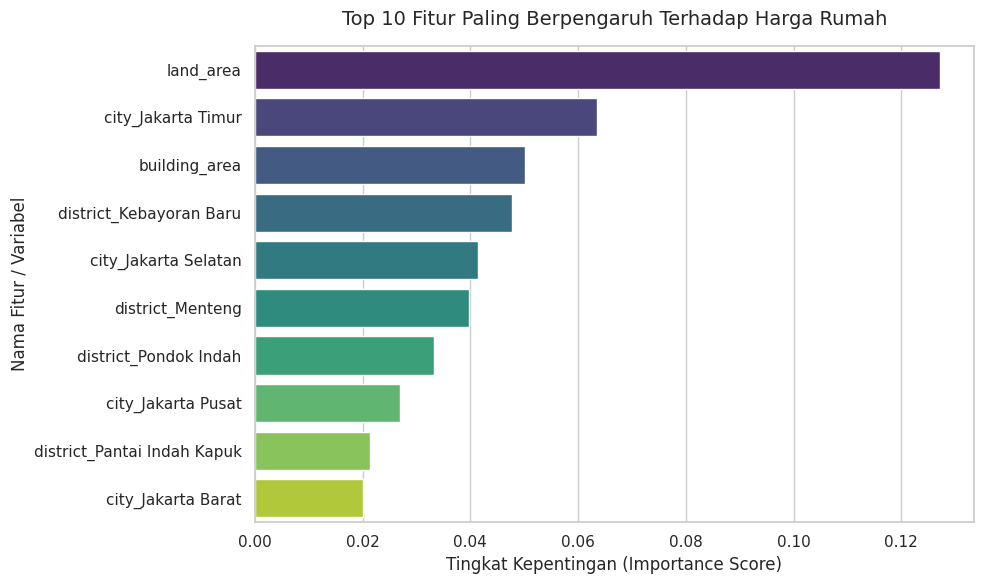

In [ ]:
# Mengambil nama fitur setelah proses One-Hot Encoding dari preprocessor
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))
all_features = numerical_features + encoded_cat_features

# Mengambil nilai penting fitur dari model berbasis pohon
importances = model_terbaik.feature_importances_

# Membuat DataFrame untuk 10 Fitur Paling Berpengaruh
df_importance = pd.DataFrame({
    'Fitur': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Importance', y='Fitur', palette='viridis')
plt.title('Top 10 Fitur Paling Berpengaruh Terhadap Harga Rumah', fontsize=14, pad=15)
plt.xlabel('Tingkat Kepentingan (Importance Score)', fontsize=12)
plt.ylabel('Nama Fitur / Variabel', fontsize=12)
plt.tight_layout()
plt.show()